#**Our Pipline:**
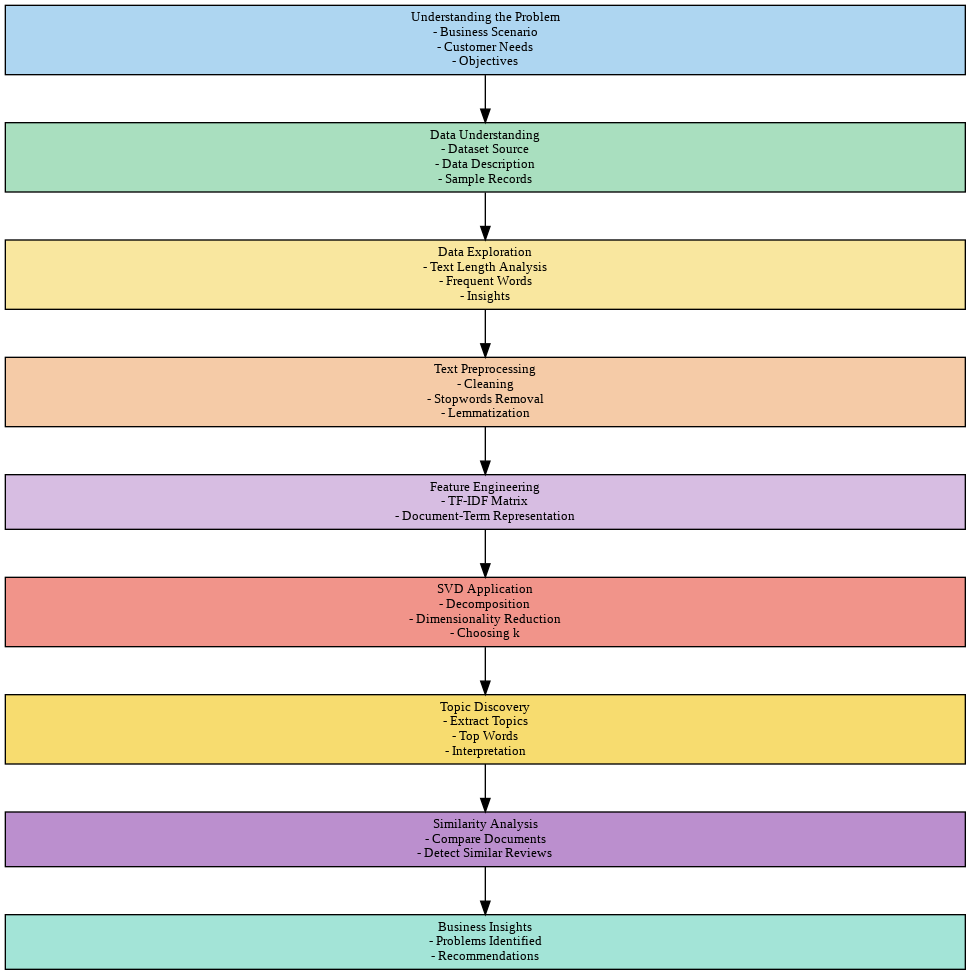

#**1-Understanding the Customer Problem**
-The **company** in our scenario is an **e-commerce platform:Amazon** that **sells food products** and **receives a large number of customer reviews daily**.

-The company receives thousands of **customer reviews** every day, but it is **difficult** to **manually analyze** and understand **what customers are saying about the products**.

-**Analyzing customer text is important** because it **helps the company** **understand customer opinions**, **detect common issues**, and **identify areas of improvement**. **Reviews** often **contain valuable feedback** about **product quality, taste, packaging, and delivery experience**.

-**Topic discovery** using **techniques** such as **LSA** helps at:
- Automatically extract **hidden topics** from a large collection of reviews.
- Understand **common concerns** like taste, delivery, packaging, price, and product quality.
- Group reviews for **better analysis**, **recommendations**, or **duplicate detection**.

# **2.Data Understanding**
The dataset used in this project is the **Amazon Fine Food Reviews dataset**, which was downloaded from Kaggle. It contains a large collection of customer reviews for food products sold on Amazon.

***Dataset Source***

https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews


---



It is originally collected from Amazon customer reviews.
The full dataset contains approximately **568,454 reviews**.
For this project, **a sample of 50,000 reviews** was used.


---
Each record represents a customer review, including fields such as **product ID**, **user ID**, **score**, and **review text**.
Example: **“This product has a great taste and I really love"**



---

The dataset contains **customer reviews**, which are unstructured text data.
These reviews express customer opinions, experiences, and satisfaction regarding food products, including aspects such as taste, quality, packaging, and delivery.


---

This dataset represents a real-world scenario where an e-commerce platform like Amazon receives a large volume of customer reviews daily.

Manually analyzing such a large number of reviews is **difficult and time-consuming**. Therefore, text analysis techniques are required to automatically **extract useful insights**, such as customer satisfaction, common issues, and product preferences.

This helps businesses



*   **improve product quality**
*    **enhance customer experience**


*   **make data-driven decisions**






# **part 1 :EDA**

In [ ]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
!pip install wordcloud
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import warnings
import re
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [ ]:
df = pd.read_csv("/content/Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df = df.sample(50000, random_state=42)
print(df.shape)
print(df.columns)
print(df.info())
df.describe()

(50000, 10)
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 165256 to 469239
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      50000 non-null  int64 
 1   ProductId               50000 non-null  object
 2   UserId                  50000 non-null  object
 3   ProfileName             50000 non-null  object
 4   HelpfulnessNumerator    50000 non-null  int64 
 5   HelpfulnessDenominator  50000 non-null  int64 
 6   Score                   50000 non-null  int64 
 7   Time                    50000 non-null  int64 
 8   Summary                 49999 non-null  object
 9   Text                    50000 non-null  object
dtypes: int64(5), object(5)
memory usage: 4.2+ MB
None


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04
mean,284596.340540,1.733040,2.211020,4.191400,1.295939e+09
std,164339.377524,7.103736,7.750015,1.304715,4.819463e+07
min,3.000000,0.000000,0.000000,1.000000,9.482400e+08
25%,142470.750000,0.000000,0.000000,4.000000,1.270944e+09
50%,283403.500000,0.000000,1.000000,5.000000,1.310861e+09
75%,426937.000000,2.000000,2.000000,5.000000,1.332547e+09
max,568446.000000,454.000000,462.000000,5.000000,1.351210e+09


In [ ]:
df.drop("Summary", axis=1, inplace=True)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Text
165256,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Having tried a couple of other brands of glute...
231465,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,My cat loves these treats. If ever I can't fin...
427827,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,A little less than I expected. It tends to ha...
433954,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,"First there was Frosted Mini-Wheats, in origin..."
70260,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,and I want to congratulate the graphic artist ...


In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Text,0


In [ ]:
print(f'Before removing duplicates: {df.shape[0]:,} rows')

Before removing duplicates: 50,000 rows


In [ ]:
df = df.drop_duplicates(subset='Text')
print(f'After removing duplicates: {df.shape[0]:,} rows')

After removing duplicates: 46,318 rows


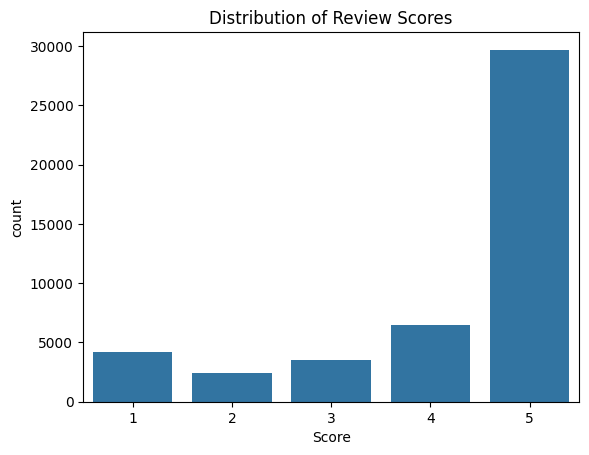

In [ ]:
sns.countplot(x="Score", data=df)
plt.title("Distribution of Review Scores")
plt.show()

# **Insight**
**“The distribution is highly skewed toward score 5, which suggests a positive rating bias where most users tend to give very high ratings compared to low ratings.”**

In [ ]:
df['review_length'] = df['Text'].apply(lambda x: len(str(x).split()))

In [ ]:
df['review_length'].describe()

,review_length
count,46318.000000
mean,79.495747
std,76.891607
min,4.000000
25%,33.000000
50%,56.000000
75%,98.000000
max,1901.000000


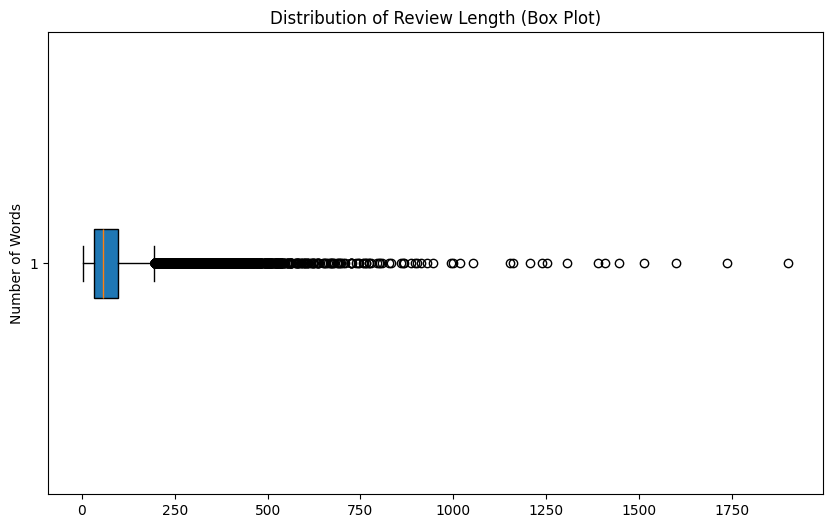

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['review_length'], vert=False, patch_artist=True)
plt.title("Distribution of Review Length (Box Plot)")
plt.ylabel("Number of Words")
plt.show()


# **Insight**
**"Most reviews are short (median = 56 words), but some are extremely long (up to 1901 words).
This shows that while many people write concise reviews, a few write very detailed ones."**

In [ ]:
from collections import Counter

words = " ".join(df["Text"].astype(str)).split()

word_freq = Counter(words)
word_freq.most_common(20)

[('the', 131373),
 ('I', 112582),
 ('and', 99171),
 ('a', 94150),
 ('to', 80220),
 ('of', 63621),
 ('is', 57558),
 ('it', 51271),
 ('for', 41930),
 ('in', 41655),
 ('this', 39541),
 ('that', 32080),
 ('my', 29542),
 ('with', 27307),
 ('have', 26960),
 ('but', 26245),
 ('was', 24867),
 ('are', 24851),
 ('not', 23154),
 ('you', 22676)]

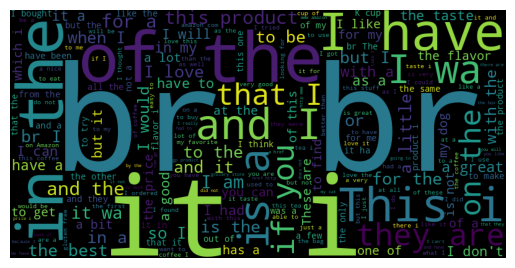

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["Text"].astype(str))

wordcloud = WordCloud(width=800, height=400,stopwords=set()).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# **Insight**
**The most frequent words such as “the”, “I”, “and”, “to”, and “of” are common English stop words.
This indicates that many high-frequency words do not carry strong meaning and should be removed during text preprocessing.**

In [ ]:
top_products = df['ProductId'].value_counts().head(10)
top_products

,count
ProductId,
B007JFMH8M,84
B003B3OOPA,73
B0026RQTGE,60
B000NMJWZO,57
B007Y59HVM,55
B006MONQMC,53
B002IEZJMA,53
B005ZBZLT4,52
B003GTR8IO,51


# **Insight**
**"Products like B007JFMH8M and B003B3OOPA have the most reviews (84 and 73).
These are likely popular or frequently purchased items on the platform."**

In [ ]:
top_users = df['UserId'].value_counts().head(10)
top_users

,count
UserId,
AY12DBB0U420B,38
A1YUL9PCJR3JTY,36
A3OXHLG6DIBRW8,33
A281NPSIMI1C2R,32
A1Z54EM24Y40LL,21
AQQLWCMRNDFGI,17
AY1EF0GOH80EK,17
AZV26LP92E6WU,16
A2R6RA8FRBS608,16


# **Insight**
**"Some users write many reviews; the top reviewer wrote 38 reviews.
This indicates a small number of users contribute a large portion of the reviews."**

**Why we are doing this step (EDA):**

We perform Exploratory Data Analysis (EDA) to understand the dataset, identify data quality issues such as duplicates and noise, and explore general patterns in customer reviews. This step helps us gain an initial understanding of the data structure and prepares it for further processing and modeling.

**How it helps solve the client’s problem:**

EDA helps transform a large, unstructured dataset into understandable patterns. By identifying issues such as duplicate reviews and noise (e.g., common words like “the”, “and”), we ensure cleaner and more reliable data for analysis. It also reveals customer behavior, such as frequent positive ratings and varying review lengths. This allows the company to move from manually reading thousands of reviews to automatically understanding trends, preparing the data for TF-IDF, topic modeling, and similarity analysis.

**What insights it provides to the business?**

The dataset was reduced from **50,000 **to** 46,318** reviews after removing duplicates, indicating repeated customer feedback.

The distribution of review scores is **highly skewed toward 5-star ratings**, showing overall positive customer satisfaction.

Most reviews are relatively short **(median ≈ 56 words)**, while a few are very long, indicating variation in customer feedback detail.

The most frequent words are common stop words such as **“the”, “and”, “to”**  highlighting the presence of noise in the raw data.

Some products have significantly more reviews than others, indicating popular and high-demand products.

A small number of users contribute many reviews, showing uneven user activity.

These insights help the business better understand customer behavior, product popularity, and overall satisfaction, enabling more informed decision-making.

##**Part 2 :Text Preprocessing**

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split() #Tokenization
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

In [ ]:
df["clean_text"] = df["Text"].apply(clean_text)

In [ ]:
df[["Text","clean_text"]].head()

,Text,clean_text
165256,Having tried a couple of other brands of glute...,tried couple brand glutenfree sandwich cooky b...
231465,My cat loves these treats. If ever I can't fin...,cat love treat ever cant find house pop top bo...
427827,A little less than I expected. It tends to ha...,little less expected tends muddy taste expecte...
433954,"First there was Frosted Mini-Wheats, in origin...",first frosted miniwheats original size frosted...
70260,and I want to congratulate the graphic artist ...,want congratulate graphic artist putting entir...


In [ ]:
words = " ".join(df["clean_text"]).split()
word_freq = Counter(words)
word_freq.most_common(20)

[('like', 21228),
 ('taste', 17241),
 ('good', 16061),
 ('one', 15341),
 ('product', 14583),
 ('flavor', 14568),
 ('coffee', 13690),
 ('great', 13194),
 ('love', 13008),
 ('tea', 12063),
 ('food', 11482),
 ('would', 9764),
 ('get', 9555),
 ('make', 8693),
 ('dog', 8100),
 ('really', 8015),
 ('time', 7964),
 ('dont', 7537),
 ('much', 7369),
 ('use', 6859)]

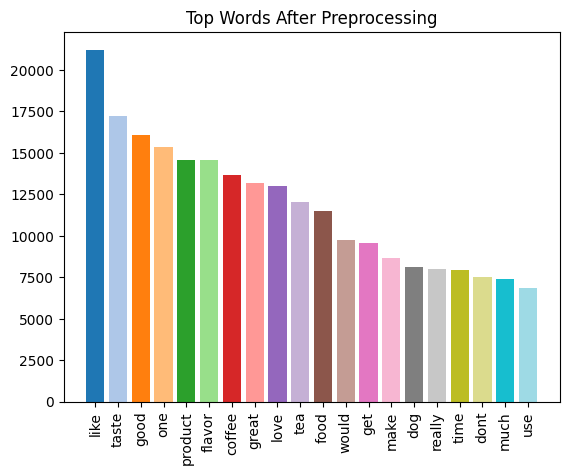

In [ ]:
common_words = word_freq.most_common(20)
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]
colors = plt.cm.tab20
plt.bar(words, counts,color=colors.colors)
plt.xticks(rotation=90)
plt.title("Top Words After Preprocessing")
plt.show()

###**Insight 1:**

The **most frequent words** in the dataset **include taste, flavor, coffee, and tea**, indicating that **many reviews focus on the taste** and **sensory experience of the products**.

###**Insight 2:**

Words such as **good, great, and love appear frequently**, suggesting that **many customers express positive opinions** about the **products.**

###**Insight 3:**

The **presence of words** like **dog** indicates that **some reviews are related to pet food products** available on Amazon.

###**Insight 4:**

Product-related terms such as **product, bag**, and make suggest that customers often **describe packaging** and **product usability** in their reviews.

##**Why we are doing this step:**  
During our EDA, we noticed that reviews contained many repeated words like "the", "and", etc., and HTML tags such as `<br>` that added noise. Cleaning the text removes these elements and converts it into a usable form for analysis.

##**How it helps solve the client's problem:**  
  By focusing only on meaningful words, this step improves the accuracy of TF-IDF, topic modeling, and similarity analysis. It ensures that patterns extracted reflect real customer concerns rather than noise.

##**What insight it provides to the business:**  
  Helps identify what matters most to customers, such as product taste, packaging, pricing, or pet-related products. This insight can guide product improvements, highlight common complaints, and inform business decisions.

# **TF-IDF Matrix**

In [ ]:
tfidf = TfidfVectorizer(max_features=3000, min_df=50, max_df=0.9, ngram_range=(1, 1),stop_words='english')

X = tfidf.fit_transform(df["clean_text"])
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1134486 stored elements and shape (46318, 2927)>

In [ ]:
# Vocabulary mapping
vocab = tfidf.get_feature_names_out()
print("Vocabulary:", vocab)

Vocabulary: ['ability' 'able' 'absolute' ... 'zip' 'ziplock' 'zukes']


In [ ]:
tfidf_scores = np.asarray(X.sum(axis=0)).flatten()
top_n = 10
top_indices = tfidf_scores.argsort()[::-1][:top_n]
top_words = vocab[top_indices]
top_scores = tfidf_scores[top_indices]

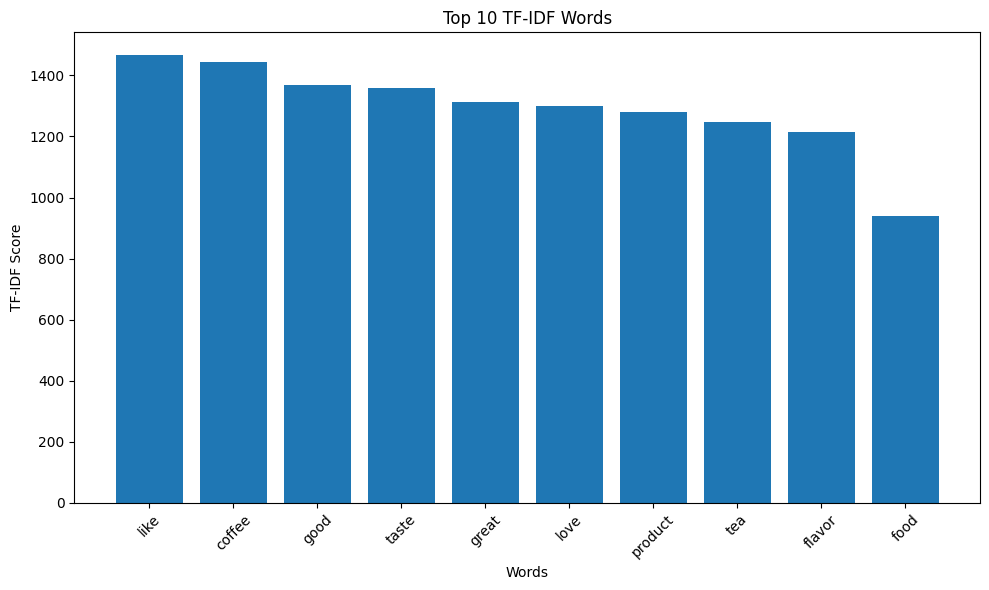

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(top_words, top_scores)
plt.xticks(rotation=45)
plt.title("Top 10 TF-IDF Words")
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.tight_layout()
plt.show()

In [ ]:
print("Shape of Document-Term Matrix:", X.shape)

Shape of Document-Term Matrix: (46318, 2927)


###**Insight 1:**
Document-Term Matrix:
- Rows: 46,318 reviews
- Columns: 3000 unigrams (features)
- Values: TF-IDF score indicating importance of each word in that review

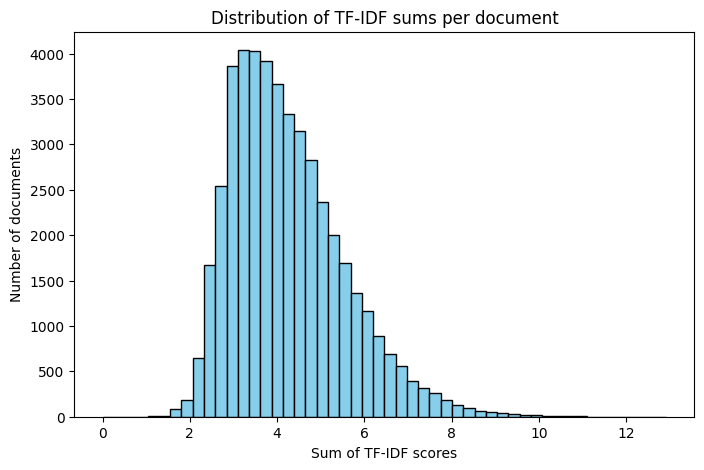

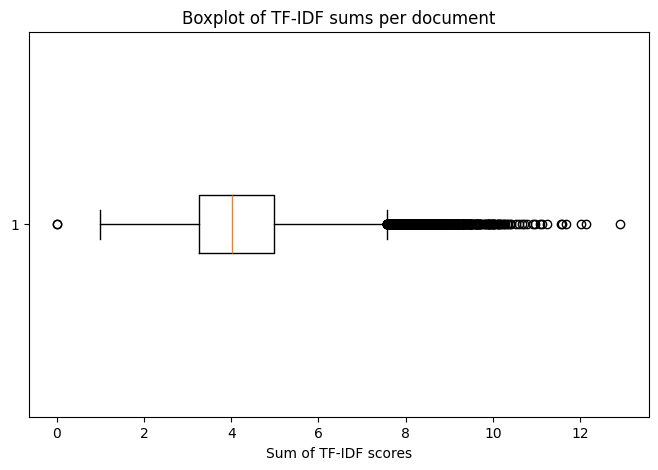

In [ ]:
# Sum of TF-IDF for each document
doc_sum = np.sum(X, axis=1)

# Histogram
plt.figure(figsize=(8,5))
plt.hist(doc_sum, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of TF-IDF sums per document")
plt.xlabel("Sum of TF-IDF scores")
plt.ylabel("Number of documents")
plt.show()

# Boxplot
doc_sum = np.array(X.sum(axis=1)).flatten()

plt.figure(figsize=(8,5))
plt.boxplot(doc_sum, vert=False)
plt.title("Boxplot of TF-IDF sums per document")
plt.xlabel("Sum of TF-IDF scores")
plt.show()

# **Insights: Distribution of TF-IDF Sums Per Document**
1. **Overall Shape — Right Skewed**

    The distribution is right-skewed, meaning the majority of reviews are short to medium length, while a smaller number of customers wrote long, detailed Reviews.

2. **The Peak (4–5 range)**

    Most documents have a TF-IDF sum between 4 and 6, with the peak sitting around 4–5. This means the average Review contains a moderate number of informative and distinctive words

3. **Low end (0–2)**

    Very few documents fall near zero. This tells us that preprocessing (removing stopwords, lemmatization) worked well — almost no empty or meaningless documents survived into the final matrix.

4. **Right tail (8–16)**

    A small number of Reviews have very high TF-IDF sums. These are likely long, detailed Reviews from customers describing complex issues — for example, a customer explaining a multi-step mortgage dispute. These documents are the most informative for LSA.
    

In [ ]:
# Average TF-IDF per document
doc_avg = np.mean(X, axis=1)

# Index of document with highest average TF-IDF
top_doc_index = np.argmax(doc_avg)
print("Index of document with highest average TF-IDF:", top_doc_index)

# content of that document
top_doc_text = df['clean_text'].iloc[top_doc_index]
print("\nText of top document:\n")
print(top_doc_text)

Index of document with highest average TF-IDF: 5489

Text of top document:

taken bragg acv eight straight month thats right ive religiously taken tablespoon time per day day id like share personal experience change body gone since started last octoberat outset acv diet pretty healthy pound yearold guy decent spare tire around waist enjoying life little much exercising little started taking acv heartburn enjoy cooking bottle kitchen already experiencing instant amazing relief energy boost bit research found cure laundry list ailment sounded good true skeptical self decided give old college try month continued taking noticed within day sleeping better eating better generally energy week wife noticed lost weight shocked one day caught fulllength mirror getting skinny college body back without exercise apparent change diet nothing different except addition acv dietenergy level first thing youll notice acv hit stomach almost instantly get natural boost last hour desire eat unhealthy food f

In [ ]:
# TF-IDF vector for this document
top_doc_vector = X[top_doc_index].toarray().flatten()

# Sort the features by TF-IDF in descending order
top_indices = top_doc_vector.argsort()[::-1]

print("\nTop 10 words in this document:")
for i in top_indices[:10]:
    print(f"{vocab[i]}: {top_doc_vector[i]:.4f}")


Top 10 words/bigrams in this document:
loss: 0.2477
weight: 0.2186
taking: 0.2027
sleep: 0.1849
month: 0.1730
day: 0.1713
getting: 0.1558
time: 0.1475
energy: 0.1452
heart: 0.1318


# **Insights**

**What this document is**

A very **long**, **detailed** Amazon product review about **Apple Cider Vinegar (ACV)** — specifically **Bragg's ACV**. The reviewer shares **8 months** of personal experience covering multiple health benefits they claim to have experienced.

**Why it has the highest TF-IDF sum**

It's **long + uses specific, rare vocabulary**:

```
"sleepwalk", "sleep paralysis", "psoriasis",
"palpitation", "bragg", "acv", "reflux",
"qtip", "lumbering", "macaroni"...
```

These words appear in very **few** other documents → **TF-IDF** rewards them heavily → **high sum.**

**Insights on the Top 10 Words**

| Word | What it signals |
|------|----------------|
| `acv` | Core topic — Apple Cider Vinegar |
| `bragg` | Specific brand being reviewed |
| `sleep`, `sleepwalk` | Personal health experience — rare vocabulary |
| `weight`, `loss` | Key benefit discussed extensively |
| `heartburn`, `reflux` | Digestive health — specific medical terms |
| `caffeine`, `palpitation` | Lifestyle changes — rare in other reviews |
| `psoriasis` | Skin condition — very rare word = high TF-IDF |

The reviewer covers **6 body systems** (sleep, weight, skin, digestion, immunity, energy) which means **many rare domain-specific words** appear together in one document → **very high TF-IDF sum.**

# **Why We Are Doing This Step**

TF-IDF transforms raw text reviews into **numerical vectors** that a machine can understand. Without this, LSA and any NLP model cannot process text. It's the **bridge between human language and mathematical computation.**

---

# **How It Helps Solve the Client's Problem**

The client has **46,318 unstructured text reviews** that are impossible to analyze manually. TF-IDF:

- **Filters out noise** — common words like "the", "is", "a" get low scores and are ignored
- **Highlights what matters** — rare, specific words like "***psoriasis***", "***sleepwalk***", "***bragg***" get high scores
- **Prepares data for LSA** — converts reviews into a **(46,318 × 3000) matrix** ready for topic discovery

Without TF-IDF, LSA has no input to work with.

---

# **What Insight It Provides to the Business**

| Insight | Business Value |
|--------|---------------|
| Most reviews have TF-IDF sum **4–6** | Average customers write **moderate** length reviews |
| Right tail reviews (sum **8–16**) | These are **power reviewers** — most informative for understanding product experience |
| Document 5489 covers **6 body systems** | Customers evaluate health products **holistically**, not just one benefit |
| Words like `"weight"`, `"sleep"`, `"energy"` dominate | Business should **market ACV around these specific benefits** |
| Very few documents near **zero** | Preprocessing was **successful** — clean data = reliable insights |

# **Singular Value Decomposition**

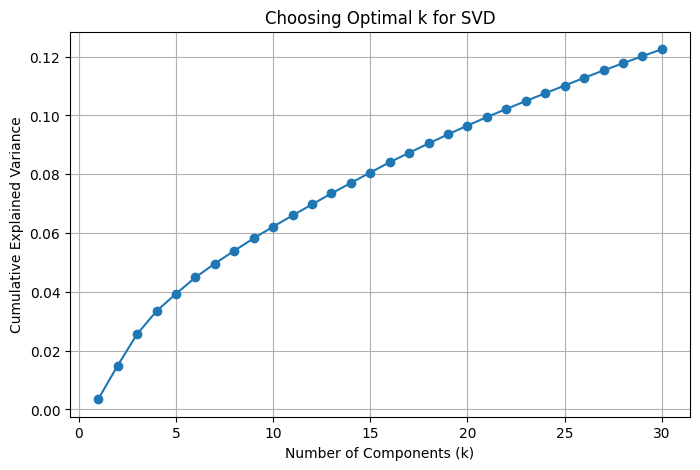

In [ ]:
svd_test = TruncatedSVD(n_components=30, random_state=42)
svd_test.fit(X)

explained_variance = np.cumsum(svd_test.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Number of Components (k)")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing Optimal k for SVD")
plt.grid(True)
plt.show()

**how I choose k ?**

To determine the optimal number of latent semantic components, we first trained the SVD model with 30 components and analyzed the cumulative explained variance.
The value of k was selected at the point where additional components provided minimal improvement in variance. This ensures a balance between dimensionality reduction and information preservation.

**Why k=20:**
- The variance curve was linear with no clear Elbow point
- k=20 gives a good balance between accuracy and speed
- Amazon Reviews is a very diverse dataset so low variance
  (~10%) is expected and normal for this type of data

In [ ]:
X_dense = X.toarray()
U, Sigma, VT = np.linalg.svd(X_dense, full_matrices=False)
k = 20
U_k = U[:, :k]
Sigma_k = np.diag(Sigma[:k])
VT_k = VT[:k, :]

print("U shape:", U_k.shape)      # (documents × 20)
print("Sigma shape:", Sigma_k.shape)  # (20 × 20)
print("VT shape:", VT_k.shape)    # (20 × terms)

#  reduced representation
X_reduced = U_k @ Sigma_k
print("X_reduced shape:", X_reduced.shape)

U shape: (46318, 20)
Sigma shape: (20, 20)
VT shape: (20, 2927)
X_reduced shape: (46318, 20)


**What each matrix represents:**

- U  ( 46,318× 20): Each row = document represented in latent space
                    Each column = how strongly the document relates to each topic

- Σ  (20 × 20):     Diagonal matrix, each value = importance of that topic
                    Larger value = more influential topic

- VT (20 × 2927):   Each row = topic, each column = term
                    Links words to hidden topics

**Why dimensionality reduction is useful:**
- Original TF-IDF Matrix was ( 46,318× 2927) = 135 million cells
- After SVD it becomes ( 46,318 × 20) = 145x smaller
- Removes noise while preserving the real meaning


### **Why you are doing this step ?**
We use Singular Value Decomposition to reduce dimensionality and select the optimal number of components (k) while preserving most of the information using explained variance


### **How it helps solve the client's problem ?**
*  Converts large, complex data into a smaller representation (X_reduced)
* Reduces noise and redundancy
* Makes tasks like clustering, topic modeling, and similarity search easier

### **What insight it provides to the business ?**
* Identifies the main topics customers talk about
* Helps understand customer preferences
* Supports product improvement and targeted marketing
* Reveals hidden patterns and relationships in the data

# **Topic Discovery**

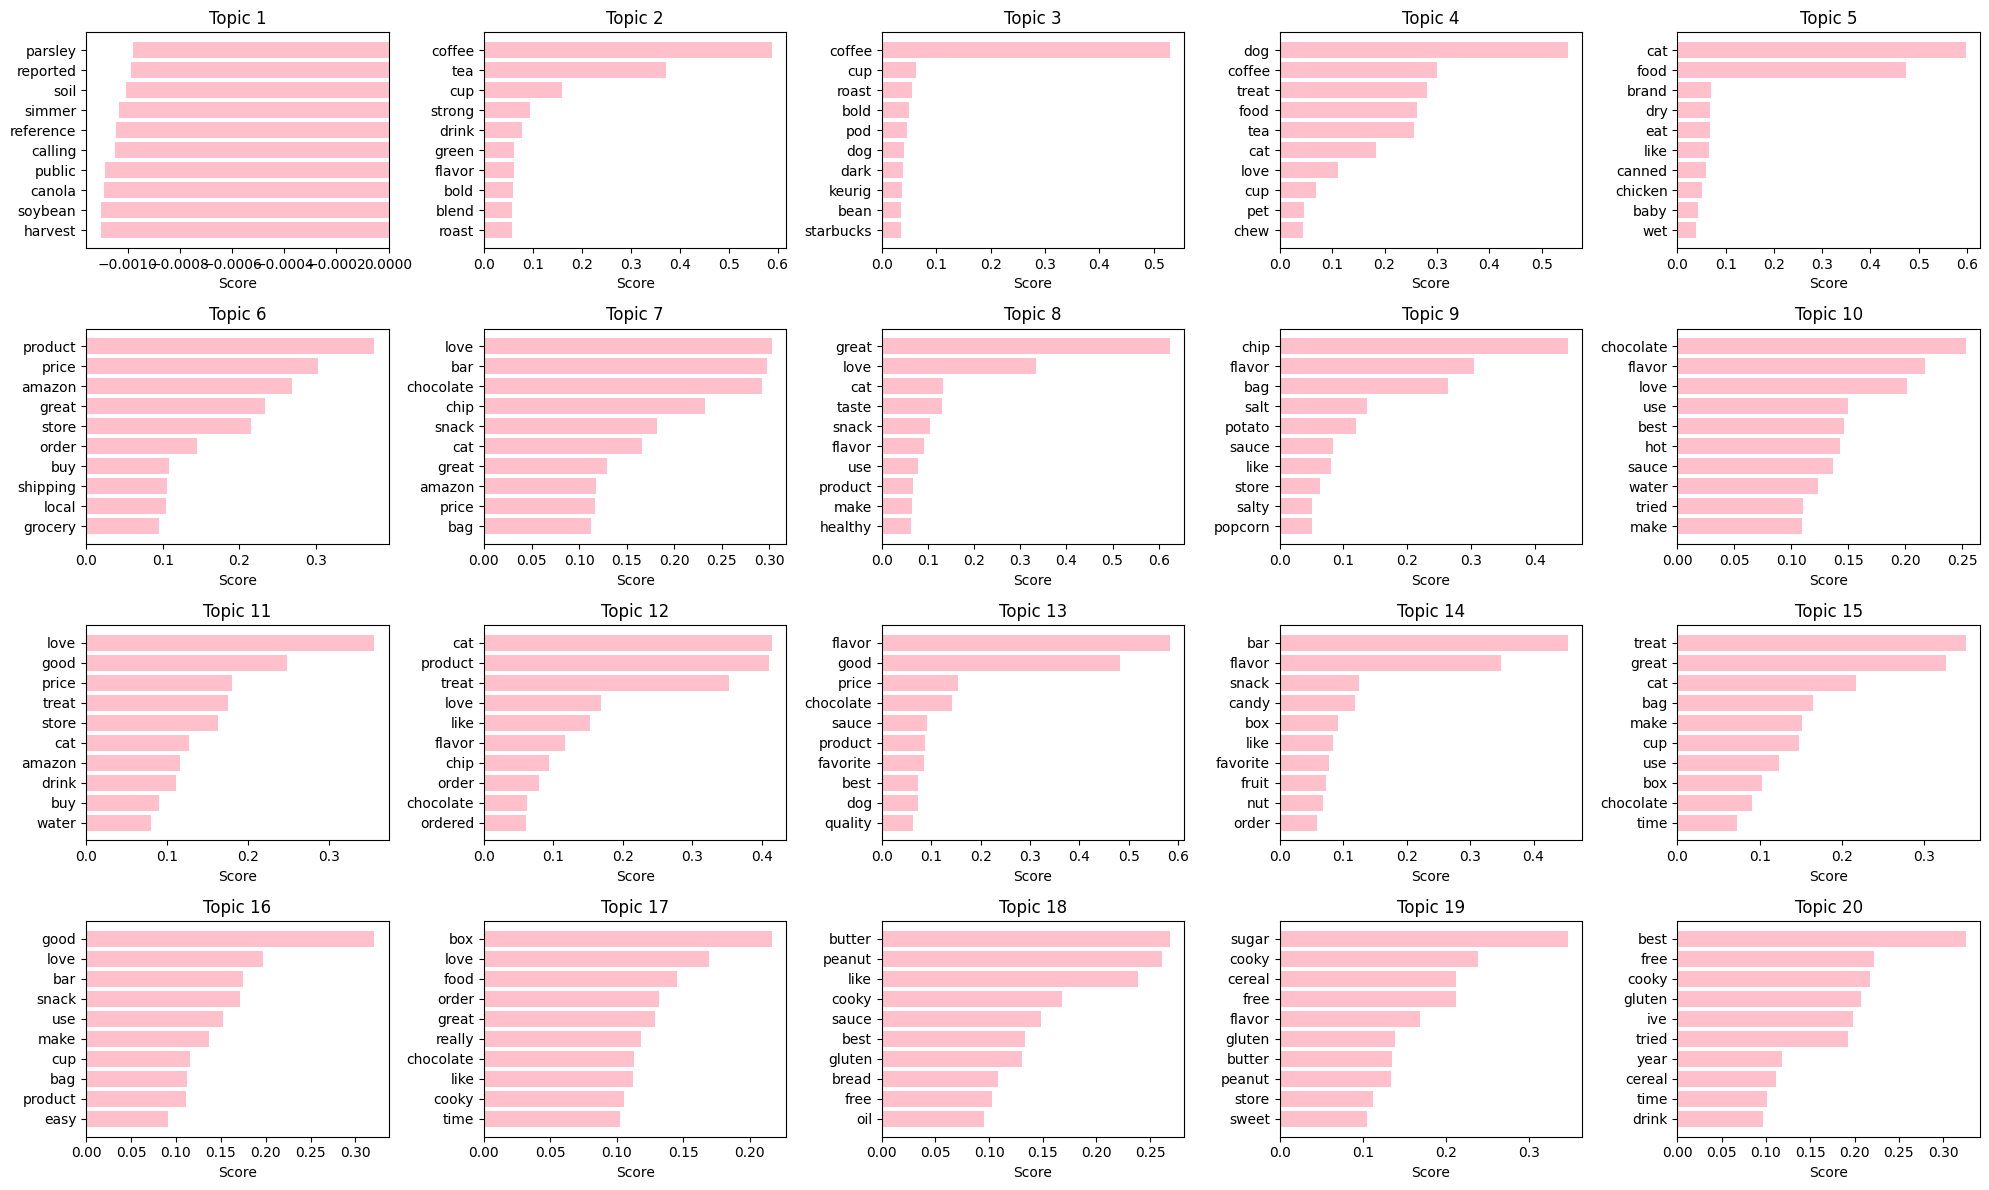

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(20, 12))
axes = axes.flatten()

for i in range(k):
    top_indices = VT_k[i].argsort()[-10:][::-1]
    top_words = [vocab[j] for j in top_indices]
    top_scores = [VT_k[i][j] for j in top_indices]

    axes[i].barh(top_words[::-1], top_scores[::-1], color='pink')
    axes[i].set_title(f"Topic {i+1}")
    axes[i].set_xlabel("Score")

plt.tight_layout()
plt.show()

## **Topic Discovery & Interpretation**

###**Topic 1**

**Top words:**

parsley, soil, soybean, harvest

**Interpretation:**

This topic relates to agriculture and food ingredients, possibly raw materials used in food production.

###**Topic 2**

**Top words:**

coffee, tea, cup, strong, drink

**Interpretation:**

This topic represents hot beverages, especially coffee and tea, focusing on strength and flavor.

###**Topic 3**

**Top words:**

coffee, roast, bold, bean, starbucks

**Interpretation:**

This topic focuses on coffee brands and roasting quality, including strong and premium coffee types.

###**Topic 4**

**Top words:**

dog, treat, food, cat, pet

**Interpretation:**

This topic represents pet food and pet treats.

###**Topic 5**

**Top words:**

cat, food, canned, chicken, eat

**Interpretation:**

This topic focuses on cat food products, especially wet/canned food.

###**Topic 6**

**Top words:**

product, price, amazon, shipping, order

**Interpretation:**

This topic relates to shopping experience, including pricing, ordering, and shipping.

###**Topic 7**

**Top words:**

chocolate, chip, snack, bar

**Interpretation:**

This topic represents snack products, especially chocolate and snack bars.

###**Topic 8**

**Top words:**

great, love, taste, healthy

**Interpretation:**

This topic reflects positive customer feedback and satisfaction.

###**Topic 9**

**Top words:**

chip, potato, salt, popcorn

**Interpretation:**

This topic is about salty snacks, such as chips and popcorn.

###**Topic 10**

**Top words:**

chocolate, hot, water, mix

**Interpretation:**

This topic represents drink mixes and chocolate beverages.

###**Topic 12**
**Top words:**

cat, product, treat, flavor

**Interpretation:**

This topic focuses on cat treats and their flavors.

###**Topic 18**

**Top words:**

peanut, butter, gluten, bread

**Interpretation:**

This topic represents dietary products, including gluten-free and peanut-based foods.

###**Topic 19**

**Top words:**

sugar, cereal, sweet, gluten

**Interpretation:**

This topic focuses on sweet and dietary food products, especially low-sugar or special diets.

# **Similarity Analysis**

In [ ]:
sample_size = 1000
X_sample = X_reduced[:sample_size]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_sample)

In [ ]:
similarity_matrix.shape

(1000, 1000)

In [ ]:
np.fill_diagonal(similarity_matrix, 0)

In [ ]:
pairs = []

for a in range(sample_size):
    for b in range(a+1, sample_size):
        pairs.append((a, b, similarity_matrix[a,b]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)

top_pairs = pairs[:5]

for p in top_pairs:
    i, j, score = p

    print("="*60)
    print("Similarity:", score)

    print("\nReview A:\n", df['Text'].iloc[i])
    print("\nReview B:\n", df['Text'].iloc[j])

Similarity: 0.9971150498502884

Review A:
 My cat gets one Whiskas Temptation treat whenever I do her nails. She's always been very compliant, but the treats have made her jello in my arms. Not so sure about the soft filling, because she swallows them whole. Ditto for tartar control. It doesn't do much for that . . . maybe would be different if my cat would chew them.

Review B:
 My cats loved the treats and gobbled them up right away.  They really enjoyed the treat, I had to hide them or one of my cats would  bat them down to the floor, and try to get into them.
Similarity: 0.9909094743312619

Review A:
 Senseo coffee pods are our favorite because of the coffee fullness and the fact that they are real coffee in paper filter pods vs plastic pods other single serve coffee makers use.  We like the Columbian and Expresso for morning, but late in the day prefer decaf coffee and and the Senseo decaf is as full flavored and pleasing as the caffeine coffee pods.  A nice way to end the day.

R

## **Finding Similar Customer Reviews**
###**Why:**

We compute similarity between customer reviews to identify reviews that describe the same issue, experience, or opinion.

Instead of reading thousands of reviews manually, similarity analysis allows us to automatically detect repeated complaints and common patterns.

###**How it helps the business:**

By comparing documents using cosine similarity on the reduced SVD representation:

- We can group similar customer complaints together

- Detect repeated issues across many users

- Reduce duplicate support tickets

- Improve automated response systems
---------------------------
###**Example 1 – Cat Treat Reviews**

Similarity Score: 0.997

**Why these reviews are similar:**

- Both reviews talk about cat treats
- Both describe how cats react strongly and positively to the product
- Both mention cats eating the treats quickly without chewing

**Insight:**

These reviews represent a shared customer experience about pet behavior with treats.

**Business value:**
- Indicates a consistent product effect (high pet acceptance)
- Can be used in marketing (e.g., “cats love this product”)
- Helps identify popular products with strong engagement
###**Example 2 – Coffee Reviews**

Similarity Score: 0.99

**Why these reviews are similar:**

- Both discuss coffee taste and quality
- Both mention flavor strength and bitterness
- Both evaluate the product based on drinking experience

**Insight:**

Customers consistently evaluate coffee products based on taste and strength.

Business value:

- Helps identify key quality factors (bitterness, flavor strength)
- Can guide product improvement
- Helps detect recurring complaints about taste
###**Example 3 – Tea Reviews**

Similarity Score: 0.98

**Why these reviews are similar:**

- Both reviews focus on tea products
- Both describe flavor, ingredients, and quality
- Both compare tea types and preferences

**Insight:**

Customers often compare tea quality and ingredients across brands.

**Business value:**

- Helps identify competitive factors in the market
- Shows importance of natural ingredients and quality perception
###**Example 4 – Dog Food Reviews**

Similarity Score: 0.98

**Why these reviews are similar:**

- Both discuss switching dog food brands
- Both describe dog reactions to the new food
- Both evaluate effectiveness of the product

**Insight:**

Customers frequently change products based on pet health or behavior.

**Business value:**

- Helps detect recurring concerns about pet health
- Useful for improving product formulation
- Helps customer support suggest alternatives
-----------------------------
##**Key Insights from Similarity Analysis**
**1- Detecting Recurring Issues**
Highly similar reviews indicate that multiple customers share the same experience.

This helps companies identify:

- Common complaints
- Frequent product issues

**2- Identifying Duplicate Reviews**
Some reviews are nearly identical in meaning.

This allows:

- Grouping duplicate tickets
- Reducing workload on support teams

**3- Understanding Customer Behavior**

Similarity reveals patterns such as:

- Customers reacting similarly to products
- Common preferences (taste, quality, pet response)

This helps in:

- Better product design
- Targeted marketing strategies

**4- Improving Customer Support Systems**

By clustering similar complaints:

- Automated replies can be generated
- Faster response time
- Better customer satisfaction
-------------------------------
##**Final Business Value**
Using SVD + similarity analysis enables:

- Automatic detection of similar customer complaints
- Identification of recurring product issues
- Better understanding of customer needs

This transforms raw text data into actionable insights for decision-making.

#**Business Insights**
###**1- Customer Priorities**

Analysis shows that customers mainly focus on:

- Taste & flavor
- Product quality
- Pet satisfaction
- Price & value

**Insight:**

Customer satisfaction is highly driven by sensory experience (taste) and perceived value.

###**2- Dominant Product Categories**

Most reviews fall into:

- Beverages (coffee, tea)
- Snacks (chips, chocolate, cookies)
- Pet food & treats

**Insight:**

These are the core business areas generating the most customer feedback.

###**3- Consistent Customer Behavior**

Similarity analysis shows that many customers:

- Describe very similar experiences
- Use similar wording when reviewing products

**Insight:**

Customer feedback is highly repetitive, meaning patterns can be reliably detected.

###**4- High-Engagement Products**

Products like:

- Pet treats
- Coffee
- Snacks

generate strong reactions (positive or negative).

**Insight:**

These products have high customer engagement and influence brand perception.

-------------------------------
##**Problems Identified**
####**1- Repeated Complaints About Taste**
- Some products are described as too bitter or too strong
- Others require additions (like creamer) to be acceptable

**Problem:**

Inconsistent flavor quality across products.

####**2- Product Performance Issues (Pet Products)**
- Pets sometimes swallow treats without chewing
- Some products don’t achieve intended benefits (e.g., tartar control)

**Problem:**

Product design may not fully meet its functional claims.

####**3- Inconsistent Customer Experience**
Some customers love a product, others strongly dislike it

**Problem:**

Lack of consistency in product quality or expectations.

####**4- Repetitive Customer Issues**
Many reviews describe the same experience

**Problem:**

Duplicate complaints
Hard to manage large volumes of feedback manually
####**5- Decision Confusion for Customers**
Customers compare many products (especially tea & coffee)

**Problem:**

Lack of clear differentiation between products.

-------------------------------
##**Recommendations**
####**1- Improve Product Quality Consistency**
- Standardize flavor profiles
- Reduce extreme variations (too bitter / too weak)

**Benefit:**

Higher customer satisfaction and fewer complaints.

####**2- Enhance Product Design (Pet Products)**
- Improve treat texture to encourage chewing
- Ensure functional claims (e.g., dental benefits) are effective

**Benefit:**

Better product performance and trust.

####**3- Implement Automated Complaint Grouping**
Use similarity analysis to cluster similar reviews

**Benefit:**

Faster customer support
Reduced duplicate tickets
Better issue tracking
####**4- Focus on High-Impact Categories**
Prioritize improvements in:
Coffee
Snacks
Pet products

**Benefit:**

Maximum business impact from improvements.

####**5- Improve Product Positioning & Communication**
Clearly describe:
Taste profile
Ingredients
Target customers

**Benefit:**

Reduces customer confusion and mismatched expectations.

####**6- Use Insights for Product Development**
- Use frequent keywords (taste, flavor, quality)
- Monitor recurring complaints

**Benefit:**

Data-driven product improvements.


-------------------------------
